#  Customer Churn Analysis

##  Project Overview
This project analyzes customer churn behavior in a banking dataset to identify key drivers behind customer attrition. The goal is to help businesses reduce churn by targeting high-risk segments and improving retention strategies.
##  Objectives
- Measure overall churn rate
- Identify high-risk customer segments
- Analyze impact of demographics and financial attributes
- Provide actionable business recommendations
## Table of Contents
1. Libraries & Setup
2. Data Loading
3. Data Quality Check
4. Exploratory Data Analysis
5. Key Findings & Recommendations

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
import os

os.makedirs("charts", exist_ok=True)

##  Dataset Description

The dataset contains customer-level information including:

- Credit Score
- Geography
- Gender
- Age
- Balance
- Number of Products
- Active Status
- Churn Status (Exited)

Each row represents a unique customer.

In [3]:
df = pd.read_csv("C:/project_2/data/churn_cleaned.csv")
df.head()

,customer_id,surname,credit_score,geography,gender,age,tenure,balance,num_of_products,has_creditcard,is_activemember,estimated_salary,exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,1,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,0,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


##  Data Preparation

- Verified dataset structure and data types
- Checked for missing or inconsistent values
- Ensured target variable is binary (0/1)
- Created derived features for better analysis

In [4]:
df.shape

(10000, 13)

In [5]:
df.columns

Index(['customer_id', 'surname', 'credit_score', 'geography', 'gender', 'age',
       'tenure', 'balance', 'num_of_products', 'has_creditcard',
       'is_activemember', 'estimated_salary', 'exited'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   surname           10000 non-null  object 
 2   credit_score      10000 non-null  int64  
 3   geography         10000 non-null  object 
 4   gender            10000 non-null  object 
 5   age               10000 non-null  int64  
 6   tenure            10000 non-null  int64  
 7   balance           10000 non-null  float64
 8   num_of_products   10000 non-null  int64  
 9   has_creditcard    10000 non-null  int64  
 10  is_activemember   10000 non-null  int64  
 11  estimated_salary  10000 non-null  float64
 12  exited            10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


In [7]:
df.isnull().sum()

customer_id         0
surname             0
credit_score        0
geography           0
gender              0
age                 0
tenure              0
balance             0
num_of_products     0
has_creditcard      0
is_activemember     0
estimated_salary    0
exited              0
dtype: int64

##  Business Questions

1. What is the overall churn rate?
2. Which countries have the highest churn?
3. Does age impact churn behavior?
4. Are inactive customers more likely to churn?
5. How does number of products influence churn?
6. What are the high-risk customer segments?

## Overall Churn Analysis

In [8]:
total_customers = len(df)
churned_customers = df['exited'].sum()
retained_customers = total_customers - churned_customers
churn_rate = (churned_customers / total_customers) * 100

print(f"Total Customers: {total_customers}")
print(f"Churned Customers: {churned_customers}")
print(f"Retained Customers: {retained_customers}")
print(f"Overall Churn Rate: {churn_rate:.2f}%")

Total Customers: 10000
Churned Customers: 2037
Retained Customers: 7963
Overall Churn Rate: 20.37%


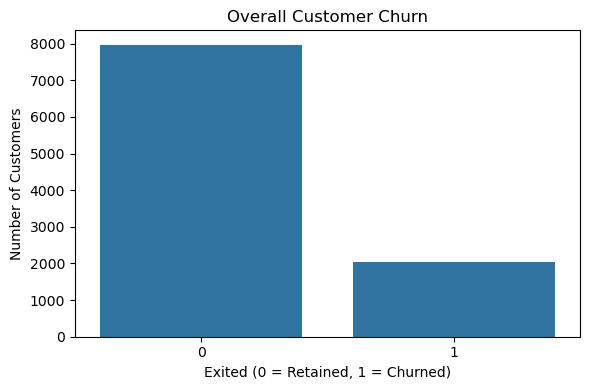

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='exited', data=df)
plt.title('Overall Customer Churn')
plt.xlabel('Exited (0 = Retained, 1 = Churned)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig("charts/overall_churn.png")
plt.show()

**Insight:**

Approximately 20% of customers have churned, indicating a significant customer attrition level.

##  Churn Analysis by Categories

In [10]:
country_churn = df.groupby('geography')['exited'].mean().sort_values(ascending=False)
country_churn

geography
Germany    0.324432
Spain      0.166734
France     0.161548
Name: exited, dtype: float64

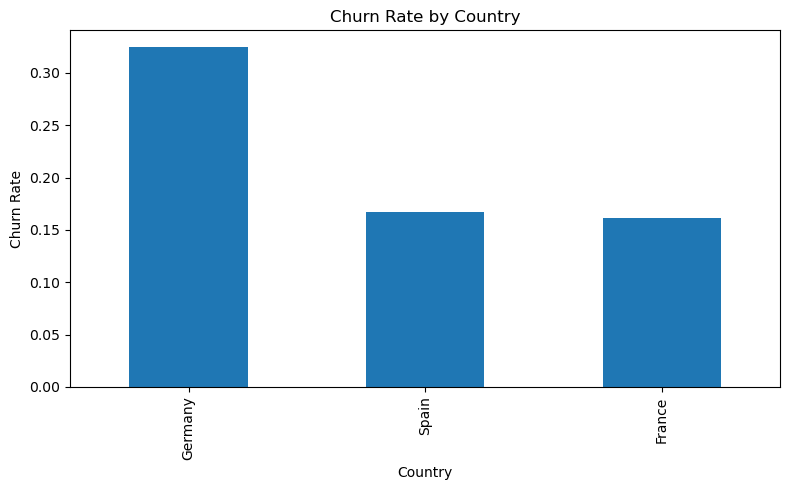

In [11]:
plt.figure(figsize=(8,5))
country_churn.plot(kind='bar')
plt.title('Churn Rate by Country')
plt.xlabel('Country')
plt.ylabel('Churn Rate')
plt.tight_layout()
plt.savefig("charts/churn_by_country.png")
plt.show()

**Insight:**

Germany has the highest churn rate at ~32% — nearly double France's 16% and well above the 20.4% baseline. This makes Germany the single most critical geography for retention intervention.

In [12]:
gender_churn = df.groupby('gender')['exited'].mean().sort_values(ascending=False)
gender_churn

gender
Female    0.250715
Male      0.164559
Name: exited, dtype: float64

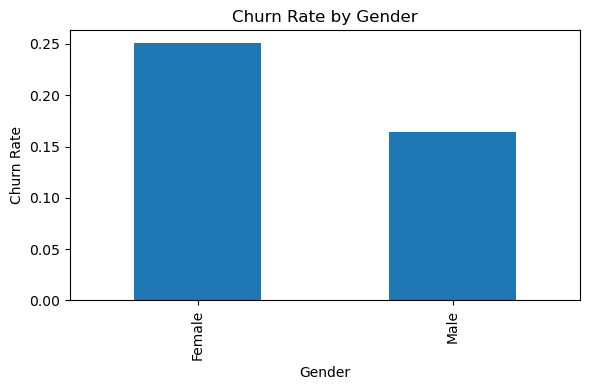

In [13]:
plt.figure(figsize=(6,4))
gender_churn.plot(kind='bar')
plt.title('Churn Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Churn Rate')
plt.tight_layout()
plt.savefig("charts/churn_by_gender.png")
plt.show()

### Churn by Gender

**Insight:**  
Female customers show a higher churn rate (25.07%) than male customers (16.46%), indicating that churn is not evenly distributed across gender segments. This may point to differences in customer experience, product alignment, or engagement patterns that deserve further investigation.

In [14]:
product_churn = df.groupby('num_of_products')['exited'].mean().sort_index()
product_churn

num_of_products
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: exited, dtype: float64

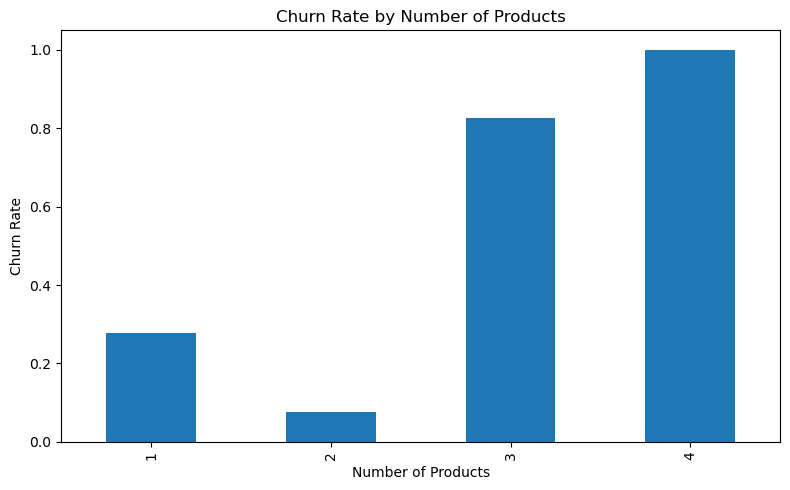

In [15]:
plt.figure(figsize=(8,5))
product_churn.plot(kind='bar')
plt.title('Churn Rate by Number of Products')
plt.xlabel('Number of Products')
plt.ylabel('Churn Rate')
plt.tight_layout()
plt.savefig("charts/churn_by_products.png")
plt.show()

### Churn by Number of Products

**Insight:**  
Customers with two products show the strongest retention, while one-product customers are more likely to churn. Although churn appears extremely high for customers with three or four products, those groups may have small sample sizes and should be interpreted cautiously.

##  Age Group Analysis

In [16]:
bins = [18, 30, 45, 60, 100]
labels = ['18-30', '31-45', '46-60', '60+']
df['AgeGroup'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)
df[['age', 'AgeGroup']].head()

,age,AgeGroup
0,42,31-45
1,41,31-45
2,42,31-45
3,39,31-45
4,43,31-45


In [17]:
agegroup_churn = df.groupby('AgeGroup', observed=False)['exited'].mean()

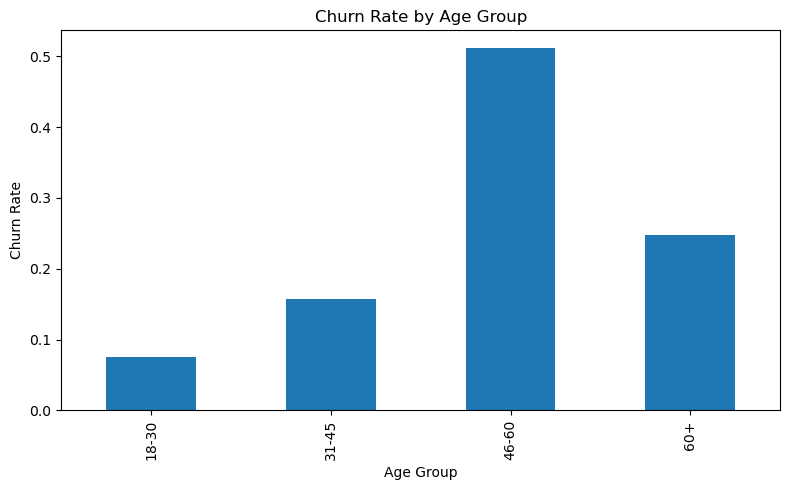

In [18]:
plt.figure(figsize=(8,5))
agegroup_churn.plot(kind='bar')

plt.title('Churn Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate')

plt.tight_layout()
plt.savefig("charts/churn_by_agegroup.png")
plt.show()

**Insight:**  
The 46–60 age group has the highest churn rate at ~51% — 2.5x the overall baseline. Younger customers (18–30) churn at just 8%, suggesting age is one of the strongest predictors of churn in this dataset.

## Final Conclusion

This analysis shows that churn is not random. It is concentrated more heavily among customers in Germany, female customers, one-product customers, and the 46–60 age group. Additionally, higher-balance churned customers indicate that the business is losing not only customers, but also valuable relationships. These findings suggest that retention strategy should focus on regional performance, product engagement, and segment-specific interventions.



## Recommendations

### 1. Launch a Germany-Specific Retention Campaign
Germany's churn rate of 32.4% is 1.6x the overall baseline — the highest of any geography. The business should investigate whether this is driven by pricing, product fit, customer service quality, or local competition. A targeted outreach programme with personalized offers for German customers should be prioritised immediately.

### 2. Investigate the Female Customer Experience
Female customers churn at 25.1% vs 16.5% for male customers. This gap suggests a potential mismatch in product offerings, communication style, or service experience for female customers. A qualitative study (surveys, exit interviews) would help identify the root cause before designing a targeted retention response.

### 3. Review the 3–4 Product Strategy
Customers holding 3 or 4 products churn at 83% and 100% respectively — far beyond any other segment. This is a strong signal of product over-selling or poor product-customer fit. The bank should audit how customers end up with 3+ products and whether this is driven by aggressive cross-selling rather than genuine need.

### 4. Build a Middle-Aged Customer Loyalty Programme
The 46–60 age group churns at 51% — 2.5x the baseline. This segment likely has the highest lifetime value and switching costs should work in the bank's favour. A dedicated loyalty or relationship banking programme (premium support, dedicated advisors, exclusive rates) could meaningfully reduce churn in this group.

### 5. Prioritise High-Balance Customer Retention
Churned customers hold higher average balances than retained ones. This means the bank is not just losing customers — it is losing its most financially valuable relationships. A high-value customer early warning system (flagging customers with balance > $100K showing disengagement signals) should be introduced.